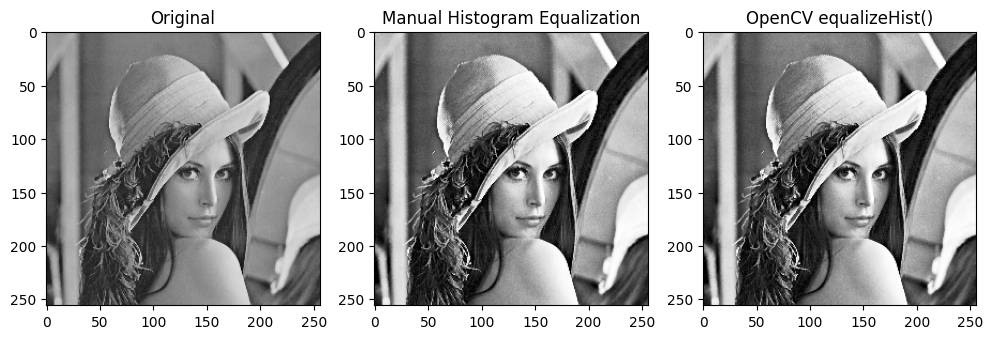

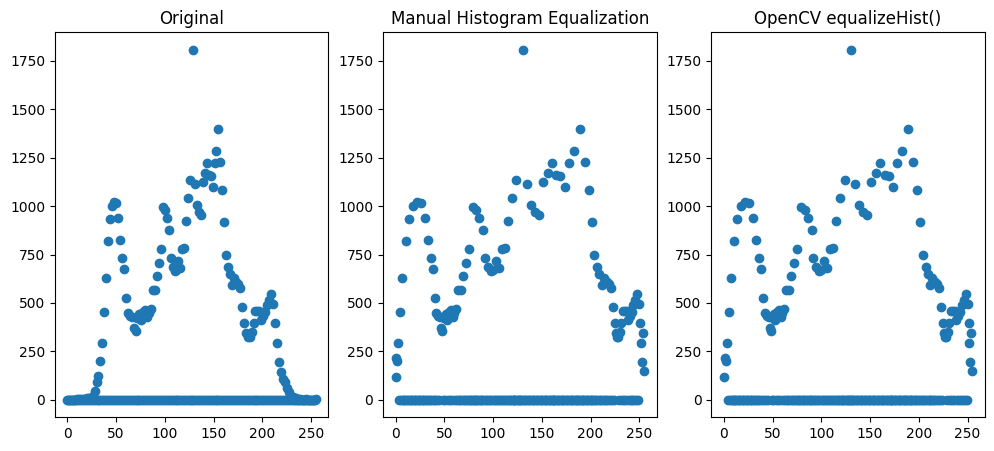

In [2]:
## Histogram Equalization
import cv2
import numpy as np
import matplotlib.pyplot as plt


img = cv2.imread("lenna.png", cv2.IMREAD_GRAYSCALE)

hist = np.zeros(256, dtype=int)

row, col = img.shape

for i in range(row):
  for j in range(col):
    hist[img[i,j]]+=1


pdf = hist / float(row*col)

# print(img.shape)
# print(hist)
# print(pdf)

cdf = np.zeros(256, dtype=float)
cdf[0] = pdf[0]
for i in range(1,256):
  cdf[i] = cdf[i-1] + pdf[i]

mapping = np.round(cdf * 255).astype(np.uint8)

# print(mapping)

output = np.zeros_like(img)
for i in range(row):
  for j in range(col):
    output[i,j] = mapping[img[i,j]]

hist_output = np.zeros(256, dtype=int)
row, col = output.shape
for i in range(row):
  for j in range(col):
    hist_output[output[i,j]]+=1


cv2.imwrite('equalized_lena.jpg', output)






####### using builtin function ##########
output_cv = cv2.equalizeHist(img)

hist_output_cv = np.zeros(256, dtype=int)
row, col = output_cv.shape
for i in range(row):
  for j in range(col):
    hist_output_cv[output_cv[i,j]]+=1

cv2.imwrite('cv_equalized_lena.jpg', output_cv)







plt.figure(figsize=(12,5))

plt.subplot(1, 3, 1)
plt.imshow(img, cmap='gray')
plt.title('Original')


plt.subplot(1, 3, 2)
plt.imshow(output, cmap='gray')
plt.title('Manual Histogram Equalization')


plt.subplot(1, 3, 3)
plt.imshow(output_cv, cmap='gray')
plt.title('OpenCV equalizeHist()')





plt.figure(figsize=(12,5))
x_values = np.arange(256)

plt.subplot(1, 3, 1)
plt.scatter(x_values, hist)
plt.title('Original')


plt.subplot(1, 3, 2)
plt.scatter(x_values, hist_output)
plt.title('Manual Histogram Equalization')


plt.subplot(1, 3, 3)
plt.scatter(x_values, hist_output_cv)
plt.title('OpenCV equalizeHist()')

plt.show()